# 第13章: ノンパラメトリック法

## 学習目標
- 符号検定を理解し適用できる
- ウィルコクソン符号付き順位検定を理解する
- マン・ホイットニーのU検定を実行できる
- クラスカル・ウォリス検定を理解する
- スピアマンの順位相関係数を計算できる

## 📋 学習メタ情報

### 推定学習時間
**100〜130分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

ノンパラメトリック検定は、分布の形を仮定せずに使える頑健な手法です。正規性の前提が疑わしい場合や、順序データの分析に有用です。

### 実世界での応用

**満足度調査**: 順序尺度のデータに対してMann-Whitney U検定を使用

**中央値の比較**: 外れ値に頑健な中央値の検定

**適合度検定**: Kolmogorov-Smirnov検定でデータの分布を確認

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 13.1 ノンパラメトリック法の概要

### パラメトリック vs ノンパラメトリック
- **パラメトリック法**: 母集団分布の形を仮定（正規分布など）
- **ノンパラメトリック法**: 分布の仮定を必要としない

### ノンパラメトリック法の特徴
- 順位や符号に基づく
- 外れ値に頑健
- 小標本でも使用可能
- 検出力はパラメトリック法より低い場合がある

## 13.2 符号検定 (Sign Test)

### 概要
中央値についての検定。各観測値が帰無仮説の値より大きいか小さいかの符号のみを使用。

### 検定統計量
$H_0: \text{median} = m_0$ の下で、正の符号の数 $S$ は二項分布に従う:
$$S \sim \text{Binomial}(n, 0.5)$$

符号検定
H0: median = 5

サンプルサイズ: 20
標本中央値: 6.08

正の符号: 15
負の符号: 5
タイ: 0

p値 = 0.0414


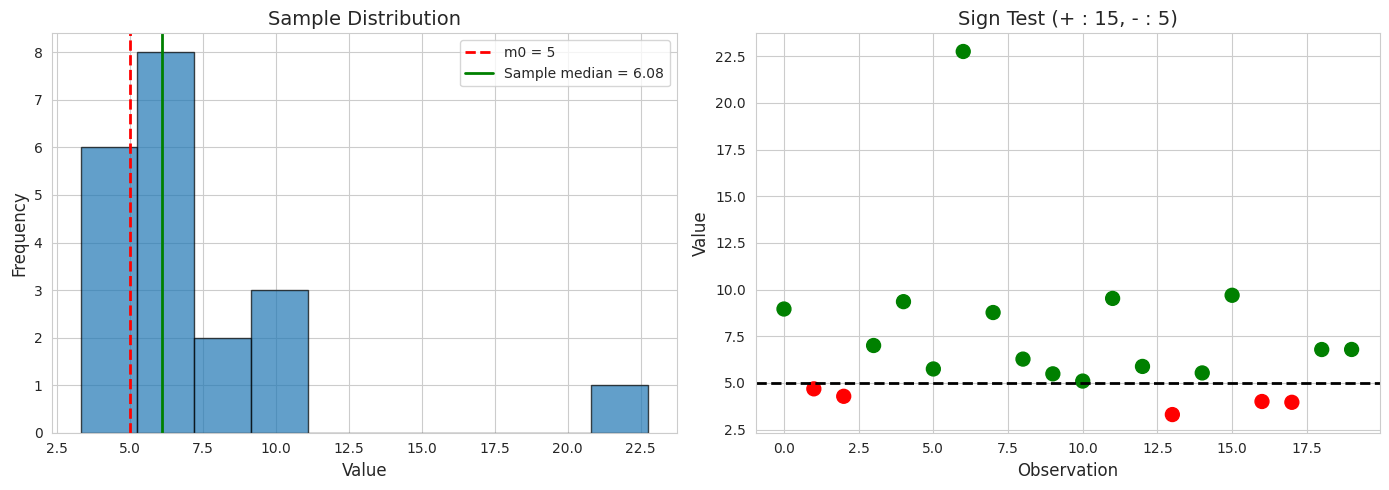

In [2]:
# 符号検定の例
np.random.seed(123)

# Sample data (skewed distribution)
n = 20
sample = np.random.exponential(5, n) + 3  # Median > 3

# Test H0: median = 5
m_0 = 5

# Count positive and negative signs
positive = np.sum(sample > m_0)
negative = np.sum(sample < m_0)
ties = np.sum(sample == m_0)

# Exclude ties
n_effective = positive + negative

# Two-sided p-value (using binomial test)
p_value = 2 * min(stats.binom.cdf(min(positive, negative), n_effective, 0.5),
                  1 - stats.binom.cdf(max(positive, negative) - 1, n_effective, 0.5))
p_value = min(p_value, 1.0)

print("符号検定")
print("="*50)
print(f"H0: median = {m_0}")
print(f"\nサンプルサイズ: {n}")
print(f"標本中央値: {np.median(sample):.2f}")
print(f"\n正の符号: {positive}")
print(f"負の符号: {negative}")
print(f"タイ: {ties}")
print(f"\np値 = {p_value:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data distribution
axes[0].hist(sample, bins=10, alpha=0.7, edgecolor='black')
axes[0].axvline(m_0, color='red', linestyle='--', linewidth=2, label=f'm0 = {m_0}')
axes[0].axvline(np.median(sample), color='green', linewidth=2, label=f'Sample median = {np.median(sample):.2f}')
axes[0].set_xlabel('Value', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Sample Distribution', fontsize=14)
axes[0].legend()

# Signs visualization
signs = np.sign(sample - m_0)
colors = ['green' if s > 0 else 'red' if s < 0 else 'gray' for s in signs]
axes[1].scatter(range(n), sample, c=colors, s=100)
axes[1].axhline(m_0, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Observation', fontsize=12)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title(f'Sign Test (+ : {positive}, - : {negative})', fontsize=14)

plt.tight_layout()
plt.show()

In [3]:
# 対応のある符号検定
np.random.seed(456)

# Paired data (before and after)
n = 15
before = np.random.normal(100, 15, n)
after = before + np.random.normal(3, 5, n)  # Small positive effect

# Differences
diff = after - before

# Sign test for H0: median(diff) = 0
positive = np.sum(diff > 0)
negative = np.sum(diff < 0)
n_effective = positive + negative

# One-sided p-value (H1: median > 0)
p_value_one = 1 - stats.binom.cdf(positive - 1, n_effective, 0.5)
p_value_two = 2 * min(p_value_one, 1 - p_value_one)

print("対応のある符号検定")
print("="*50)
print(f"H0: median(差) = 0")
print(f"\n正の差: {positive}")
print(f"負の差: {negative}")
print(f"\np値 (片側): {p_value_one:.4f}")
print(f"p値 (両側): {p_value_two:.4f}")

対応のある符号検定
H0: median(差) = 0

正の差: 14
負の差: 1

p値 (片側): 0.0005
p値 (両側): 0.0010


## 13.3 ウィルコクソン符号付き順位検定

### 概要
符号検定より検出力が高い。差の絶対値の順位に符号を付けて使用。

### 検定統計量
$$W = \sum_{i=1}^{n} R_i \cdot \text{sign}(X_i - m_0)$$

正の順位和 $W^+$ または負の順位和 $W^-$ を使用。

ウィルコクソン符号付き順位検定
H0: 差の中央値 = 0

差: [ 3  3  2 -2  3  3  3  3  2 -2  3  4]
絶対値順位: [ 8.   8.   2.5  2.5  8.   8.   8.   8.   2.5  2.5  8.  12. ]
符号付き順位: [ 8.   8.   2.5 -2.5  8.   8.   8.   8.   2.5 -2.5  8.  12. ]

W+ = 73.0
W- = 5.0



SciPy結果:
統計量 = 5.0
p値 = 0.0054


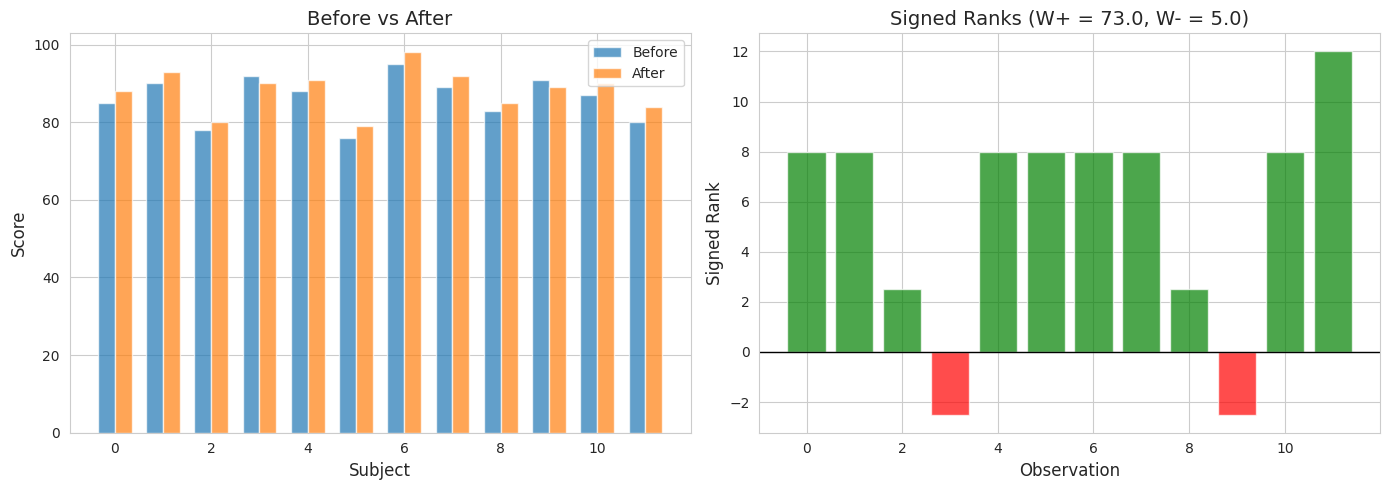

In [4]:
# ウィルコクソン符号付き順位検定
np.random.seed(789)

# Paired data
n = 12
before = np.array([85, 90, 78, 92, 88, 76, 95, 89, 83, 91, 87, 80])
after = np.array([88, 93, 80, 90, 91, 79, 98, 92, 85, 89, 90, 84])

# Differences
diff = after - before

# Remove zeros
diff_nonzero = diff[diff != 0]
n_effective = len(diff_nonzero)

# Rank absolute values
abs_diff = np.abs(diff_nonzero)
ranks = stats.rankdata(abs_diff)

# Signed ranks
signed_ranks = ranks * np.sign(diff_nonzero)

# Calculate W+ and W-
w_plus = np.sum(signed_ranks[signed_ranks > 0])
w_minus = -np.sum(signed_ranks[signed_ranks < 0])

print("ウィルコクソン符号付き順位検定")
print("="*50)
print(f"H0: 差の中央値 = 0")
print(f"\n差: {diff}")
print(f"絶対値順位: {ranks}")
print(f"符号付き順位: {signed_ranks}")
print(f"\nW+ = {w_plus}")
print(f"W- = {w_minus}")

# Use scipy for p-value
stat, p_value = stats.wilcoxon(after, before)
print(f"\nSciPy結果:")
print(f"統計量 = {stat}")
print(f"p値 = {p_value:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before vs After
x = np.arange(n)
width = 0.35
axes[0].bar(x - width/2, before, width, label='Before', alpha=0.7)
axes[0].bar(x + width/2, after, width, label='After', alpha=0.7)
axes[0].set_xlabel('Subject', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Before vs After', fontsize=14)
axes[0].legend()

# Signed ranks
colors = ['green' if s > 0 else 'red' for s in signed_ranks]
axes[1].bar(range(n_effective), signed_ranks, color=colors, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Observation', fontsize=12)
axes[1].set_ylabel('Signed Rank', fontsize=12)
axes[1].set_title(f'Signed Ranks (W+ = {w_plus}, W- = {w_minus})', fontsize=14)

plt.tight_layout()
plt.show()

## 13.4 マン・ホイットニーのU検定（ウィルコクソン順位和検定）

### 概要
2つの独立した標本が同じ分布から得られたかを検定。

### 検定統計量
全データを合わせて順位を付け、第1群の順位和 $R_1$ を計算:
$$U_1 = n_1 n_2 + \frac{n_1(n_1+1)}{2} - R_1$$

マン・ホイットニーのU検定
H0: 2群は同じ分布に従う

サンプル1: n1 = 10
サンプル2: n2 = 12

順位和: R1 = 81.0, R2 = 172.0
U1 = 94.0, U2 = 26.0

SciPy結果:
U = 26.0
p値 = 0.0272


/tmp/ipykernel_14270/3309315199.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([sample1, sample2], labels=['Sample 1', 'Sample 2'])


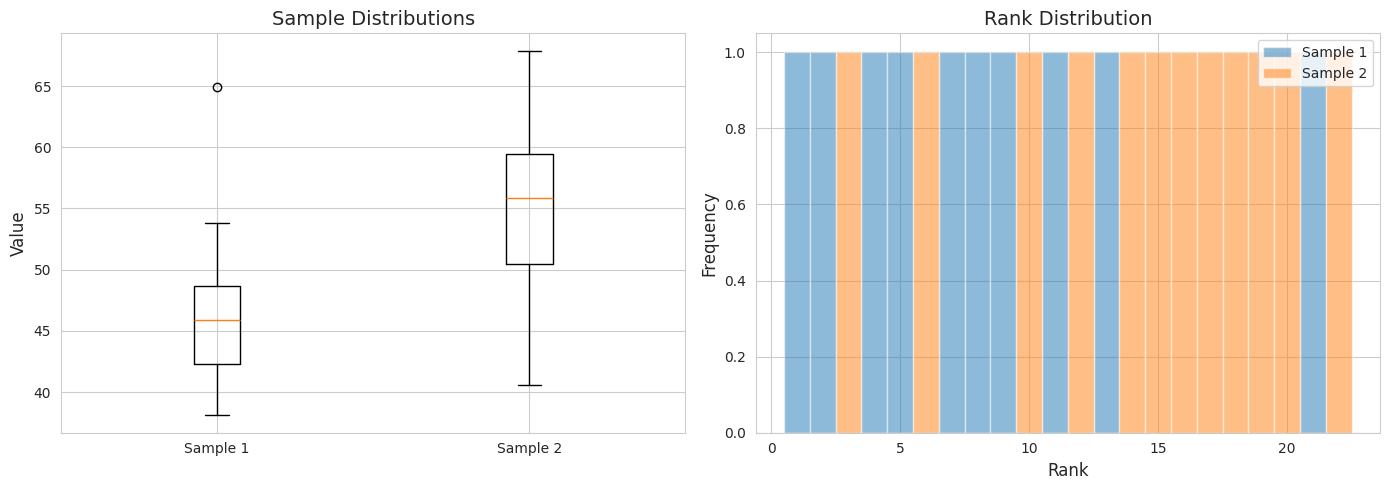

In [5]:
# マン・ホイットニーのU検定
np.random.seed(111)

# Two independent samples
n1, n2 = 10, 12
sample1 = np.random.normal(50, 10, n1)
sample2 = np.random.normal(55, 10, n2)

# Combine and rank
combined = np.concatenate([sample1, sample2])
ranks = stats.rankdata(combined)

# Rank sums
r1 = np.sum(ranks[:n1])
r2 = np.sum(ranks[n1:])

# U statistics
u1 = n1 * n2 + n1 * (n1 + 1) / 2 - r1
u2 = n1 * n2 + n2 * (n2 + 1) / 2 - r2

print("マン・ホイットニーのU検定")
print("="*50)
print(f"H0: 2群は同じ分布に従う")
print(f"\nサンプル1: n1 = {n1}")
print(f"サンプル2: n2 = {n2}")
print(f"\n順位和: R1 = {r1}, R2 = {r2}")
print(f"U1 = {u1}, U2 = {u2}")

# Use scipy
u_stat, p_value = stats.mannwhitneyu(sample1, sample2, alternative='two-sided')
print(f"\nSciPy結果:")
print(f"U = {u_stat}")
print(f"p値 = {p_value:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot([sample1, sample2], labels=['Sample 1', 'Sample 2'])
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Sample Distributions', fontsize=14)

# Rank distribution
axes[1].hist(ranks[:n1], bins=np.arange(0.5, n1+n2+1.5, 1), alpha=0.5, label='Sample 1')
axes[1].hist(ranks[n1:], bins=np.arange(0.5, n1+n2+1.5, 1), alpha=0.5, label='Sample 2')
axes[1].set_xlabel('Rank', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Rank Distribution', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

t検定とU検定の比較
Data         t-test p     U-test p    
----------------------------------------
Normal       0.3383       0.3369
Skewed       0.1095       0.0106
Outliers     0.5908       0.8604


/tmp/ipykernel_14270/1813554242.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([s1, s2], labels=['Sample 1', 'Sample 2'])
/tmp/ipykernel_14270/1813554242.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([s1, s2], labels=['Sample 1', 'Sample 2'])
/tmp/ipykernel_14270/1813554242.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([s1, s2], labels=['Sample 1', 'Sample 2'])


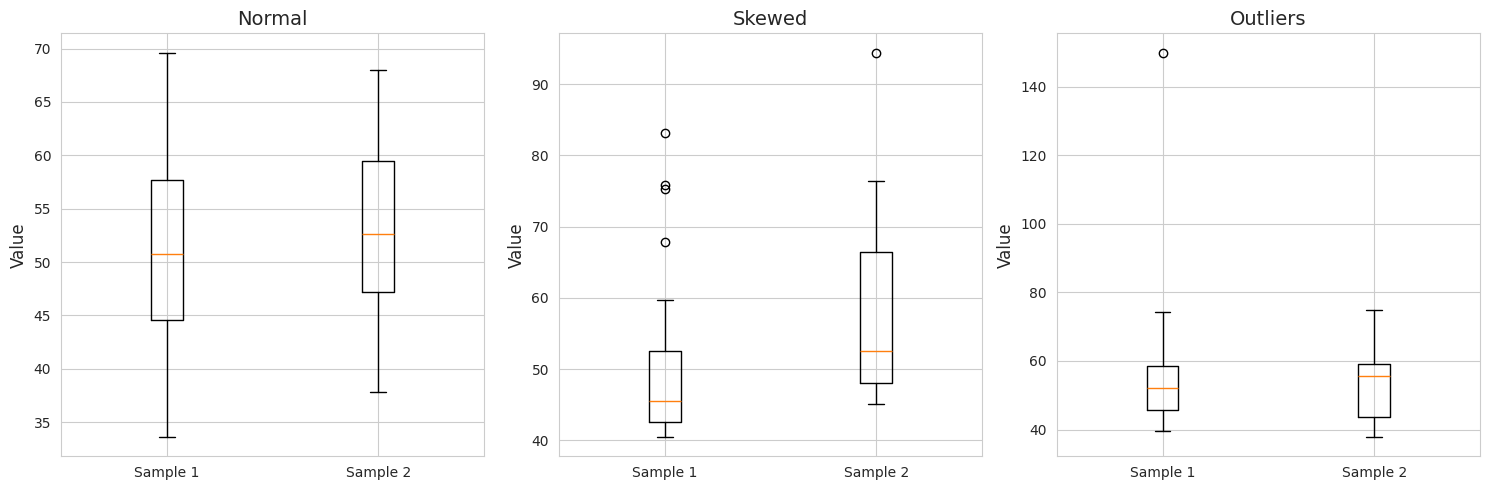

In [6]:
# U検定とt検定の比較
np.random.seed(222)

# Normal data
n1, n2 = 20, 20
normal1 = np.random.normal(50, 10, n1)
normal2 = np.random.normal(55, 10, n2)

# Skewed data (exponential)
skewed1 = np.random.exponential(10, n1) + 40
skewed2 = np.random.exponential(10, n2) + 45

# Data with outliers
outlier1 = np.random.normal(50, 10, n1)
outlier1[0] = 150  # Extreme outlier
outlier2 = np.random.normal(55, 10, n2)

datasets = [
    ('Normal', normal1, normal2),
    ('Skewed', skewed1, skewed2),
    ('Outliers', outlier1, outlier2)
]

print("t検定とU検定の比較")
print("="*60)
print(f"{'Data':12} {'t-test p':12} {'U-test p':12}")
print("-"*40)

for name, s1, s2 in datasets:
    _, p_t = stats.ttest_ind(s1, s2)
    _, p_u = stats.mannwhitneyu(s1, s2, alternative='two-sided')
    print(f"{name:12} {p_t:.4f}       {p_u:.4f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, s1, s2) in enumerate(datasets):
    axes[idx].boxplot([s1, s2], labels=['Sample 1', 'Sample 2'])
    axes[idx].set_title(name, fontsize=14)
    axes[idx].set_ylabel('Value', fontsize=12)

plt.tight_layout()
plt.show()

## 13.5 クラスカル・ウォリス検定

### 概要
3群以上の独立した標本の比較（一元配置分散分析のノンパラメトリック版）。

### 検定統計量
$$H = \frac{12}{N(N+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(N+1)$$

$H_0$ の下で近似的に $\chi^2(k-1)$ に従う。

クラスカル・ウォリス検定
H0: 全群は同じ分布に従う

グループ1: n = 15, median = 48.76
グループ2: n = 18, median = 54.70
グループ3: n = 12, median = 51.52

H統計量 = 2.859
p値 = 0.2395

比較（一元配置分散分析）:
F = 1.535, p = 0.2274


/tmp/ipykernel_14270/4085119454.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([group1, group2, group3], labels=['Group 1', 'Group 2', 'Group 3'])


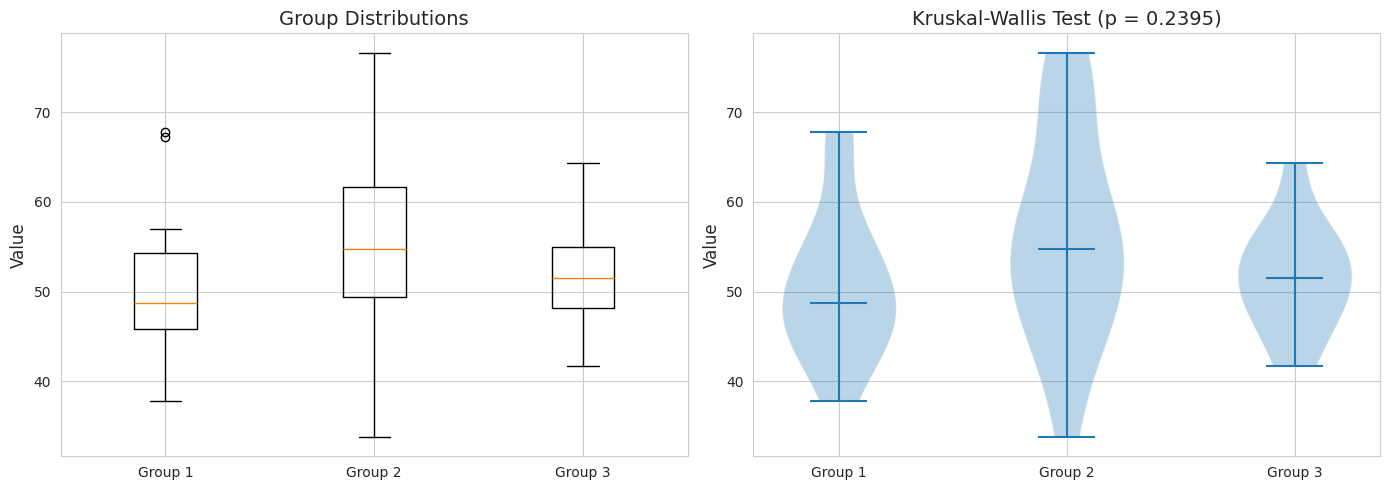

In [7]:
# クラスカル・ウォリス検定
np.random.seed(333)

# Three groups
group1 = np.random.normal(50, 10, 15)
group2 = np.random.normal(55, 10, 18)
group3 = np.random.normal(60, 10, 12)

# Kruskal-Wallis test
h_stat, p_value = stats.kruskal(group1, group2, group3)

print("クラスカル・ウォリス検定")
print("="*50)
print(f"H0: 全群は同じ分布に従う")
print(f"\nグループ1: n = {len(group1)}, median = {np.median(group1):.2f}")
print(f"グループ2: n = {len(group2)}, median = {np.median(group2):.2f}")
print(f"グループ3: n = {len(group3)}, median = {np.median(group3):.2f}")
print(f"\nH統計量 = {h_stat:.3f}")
print(f"p値 = {p_value:.4f}")

# Compare with one-way ANOVA
f_stat, p_anova = stats.f_oneway(group1, group2, group3)
print(f"\n比較（一元配置分散分析）:")
print(f"F = {f_stat:.3f}, p = {p_anova:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plots
axes[0].boxplot([group1, group2, group3], labels=['Group 1', 'Group 2', 'Group 3'])
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Group Distributions', fontsize=14)

# Violin plots
parts = axes[1].violinplot([group1, group2, group3], positions=[1, 2, 3], showmedians=True)
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(['Group 1', 'Group 2', 'Group 3'])
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title(f'Kruskal-Wallis Test (p = {p_value:.4f})', fontsize=14)

plt.tight_layout()
plt.show()

In [8]:
# Post-hoc test (Dunn's test)
# Pairwise Mann-Whitney U tests with Bonferroni correction

groups = [group1, group2, group3]
names = ['Group 1', 'Group 2', 'Group 3']
n_comparisons = 3  # C(3,2) = 3

print("事後検定（マン・ホイットニーU検定 + ボンフェローニ補正）")
print("="*50)

for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        _, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
        p_adjusted = min(p * n_comparisons, 1.0)
        print(f"{names[i]} vs {names[j]}: p = {p:.4f}, adjusted p = {p_adjusted:.4f}")

事後検定（マン・ホイットニーU検定 + ボンフェローニ補正）
Group 1 vs Group 2: p = 0.1244, adjusted p = 0.3732
Group 1 vs Group 3: p = 0.5101, adjusted p = 1.0000
Group 2 vs Group 3: p = 0.2804, adjusted p = 0.8411


## 13.6 スピアマンの順位相関係数

### 定義
順位に基づく相関係数:
$$r_s = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$$

ここで $d_i$ は順位の差。

### 性質
- $-1 \leq r_s \leq 1$
- 外れ値に頑健
- 単調関係を測定

スピアマンの順位相関係数

手計算: rs = 0.8797
SciPy: rs = 0.8797
p値 = 0.0000

ピアソン相関係数: r = 0.9206


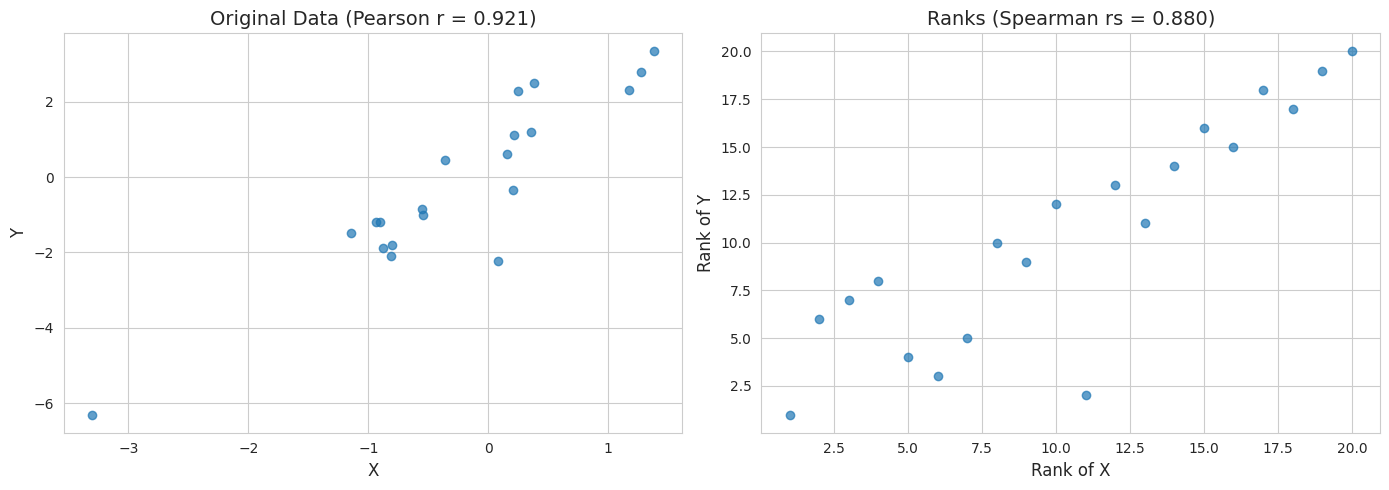

In [9]:
# スピアマンの順位相関係数
np.random.seed(444)

# Generate correlated data
n = 20
x = np.random.normal(0, 1, n)
y = 2*x + np.random.normal(0, 1, n)

# Calculate rank correlation
rank_x = stats.rankdata(x)
rank_y = stats.rankdata(y)

# Manual calculation
d = rank_x - rank_y
d_squared_sum = np.sum(d**2)
r_s_manual = 1 - 6 * d_squared_sum / (n * (n**2 - 1))

# Scipy calculation
r_s, p_value = stats.spearmanr(x, y)

# Pearson correlation for comparison
r_p, _ = stats.pearsonr(x, y)

print("スピアマンの順位相関係数")
print("="*50)
print(f"\n手計算: rs = {r_s_manual:.4f}")
print(f"SciPy: rs = {r_s:.4f}")
print(f"p値 = {p_value:.4f}")
print(f"\nピアソン相関係数: r = {r_p:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot (original values)
axes[0].scatter(x, y, alpha=0.7)
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('Y', fontsize=12)
axes[0].set_title(f'Original Data (Pearson r = {r_p:.3f})', fontsize=14)

# Scatter plot (ranks)
axes[1].scatter(rank_x, rank_y, alpha=0.7)
axes[1].set_xlabel('Rank of X', fontsize=12)
axes[1].set_ylabel('Rank of Y', fontsize=12)
axes[1].set_title(f'Ranks (Spearman rs = {r_s:.3f})', fontsize=14)

plt.tight_layout()
plt.show()

外れ値に対する頑健性

外れ値なし:
  Pearson r = 0.9704
  Spearman rs = 0.9654

外れ値あり:
  Pearson r = -0.0692  (変化: -1.0395)
  Spearman rs = 0.6917  (変化: -0.2737)


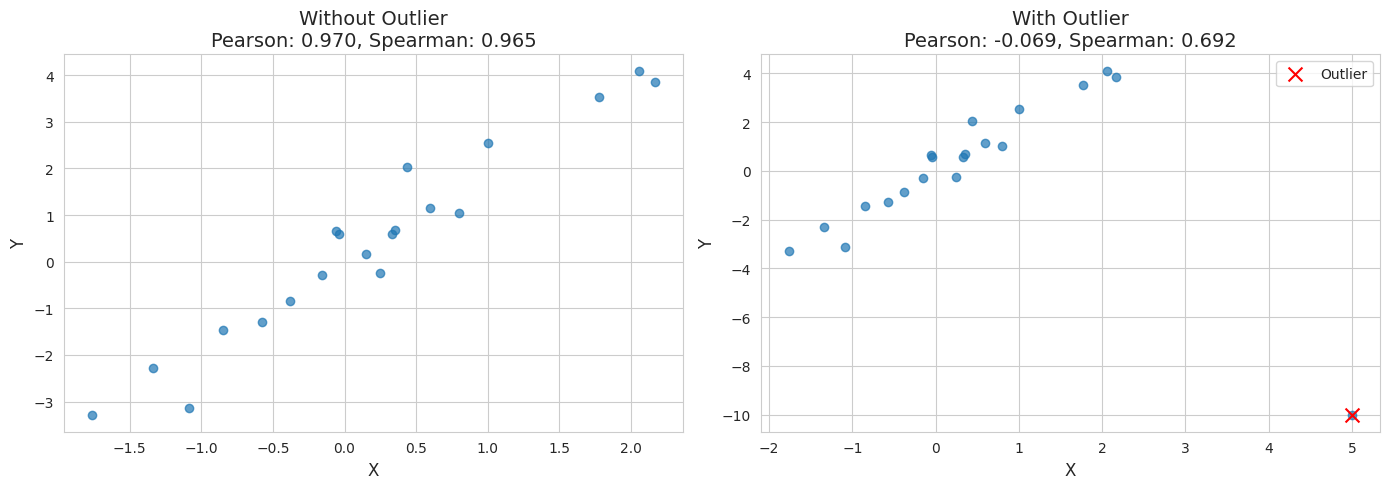

In [10]:
# 外れ値に対する頑健性
np.random.seed(555)

n = 20
x = np.random.normal(0, 1, n)
y = 2*x + np.random.normal(0, 0.5, n)

# Add outlier
x_outlier = x.copy()
y_outlier = y.copy()
x_outlier[0] = 5
y_outlier[0] = -10

# Without outlier
r_pearson, _ = stats.pearsonr(x, y)
r_spearman, _ = stats.spearmanr(x, y)

# With outlier
r_pearson_out, _ = stats.pearsonr(x_outlier, y_outlier)
r_spearman_out, _ = stats.spearmanr(x_outlier, y_outlier)

print("外れ値に対する頑健性")
print("="*50)
print(f"\n外れ値なし:")
print(f"  Pearson r = {r_pearson:.4f}")
print(f"  Spearman rs = {r_spearman:.4f}")
print(f"\n外れ値あり:")
print(f"  Pearson r = {r_pearson_out:.4f}  (変化: {r_pearson_out - r_pearson:+.4f})")
print(f"  Spearman rs = {r_spearman_out:.4f}  (変化: {r_spearman_out - r_spearman:+.4f})")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Without outlier
axes[0].scatter(x, y, alpha=0.7)
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('Y', fontsize=12)
axes[0].set_title(f'Without Outlier\nPearson: {r_pearson:.3f}, Spearman: {r_spearman:.3f}', fontsize=14)

# With outlier
axes[1].scatter(x_outlier, y_outlier, alpha=0.7)
axes[1].scatter([x_outlier[0]], [y_outlier[0]], color='red', s=100, marker='x', label='Outlier')
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('Y', fontsize=12)
axes[1].set_title(f'With Outlier\nPearson: {r_pearson_out:.3f}, Spearman: {r_spearman_out:.3f}', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 13.7 ケンドールの順位相関係数

### 定義
$$\tau = \frac{(\text{concordant pairs}) - (\text{discordant pairs})}{n(n-1)/2}$$

### 性質
- スピアマンより解釈しやすい
- タイが多いデータに適している

ケンドールの順位相関係数

τ = 0.6051
p値 = 0.0029

比較（スピアマン）: rs = 0.7160, p = 0.0027


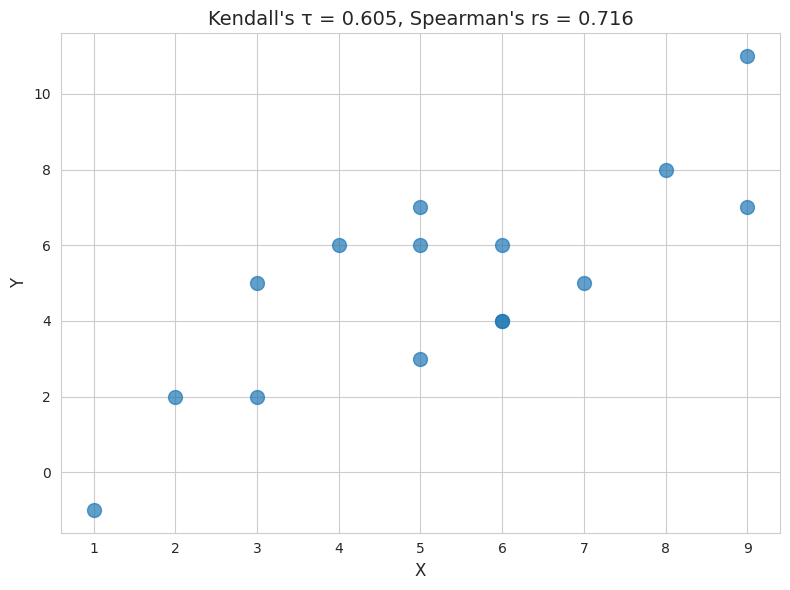

In [11]:
# ケンドールの順位相関係数
np.random.seed(666)

n = 15
x = np.random.randint(1, 10, n)
y = x + np.random.randint(-2, 3, n)

# Calculate Kendall's tau
tau, p_value = stats.kendalltau(x, y)

# Also calculate Spearman for comparison
r_s, p_s = stats.spearmanr(x, y)

print("ケンドールの順位相関係数")
print("="*50)
print(f"\nτ = {tau:.4f}")
print(f"p値 = {p_value:.4f}")
print(f"\n比較（スピアマン）: rs = {r_s:.4f}, p = {p_s:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x, y, s=100, alpha=0.7)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title(f"Kendall's τ = {tau:.3f}, Spearman's rs = {r_s:.3f}", fontsize=14)

plt.tight_layout()
plt.show()

## 13.8 検定法の選択ガイド

| 状況 | パラメトリック | ノンパラメトリック |
|------|----------------|--------------------|
| 一標本（中央値） | t検定 | 符号検定、ウィルコクソン |
| 対応あり二標本 | 対応t検定 | 符号検定、ウィルコクソン |
| 独立二標本 | t検定 | マン・ホイットニー |
| 三群以上 | ANOVA | クラスカル・ウォリス |
| 相関 | ピアソン | スピアマン、ケンドール |

## 13.9 練習問題

### 問題1
10人の患者の治療前後の血圧データが以下の通りである。符号検定とウィルコクソン符号付き順位検定を用いて、治療効果があるか検定せよ（有意水準5%）。

前: 145, 150, 140, 160, 155, 148, 142, 158, 152, 146
後: 138, 145, 135, 155, 148, 142, 140, 150, 145, 140

### 問題2
3つの店舗での待ち時間（分）が以下の通りである。クラスカル・ウォリス検定で店舗間に差があるか検定せよ。

店舗A: 5, 8, 6, 9, 7
店舗B: 10, 12, 8, 15, 11, 14
店舗C: 6, 4, 7, 5, 8, 6, 5

### 問題3
以下のデータについて、スピアマンの順位相関係数を計算し、有意性を検定せよ。

X: 3, 5, 2, 8, 6, 1, 7, 4
Y: 4, 7, 3, 9, 5, 2, 8, 6

In [12]:
# 問題1の解答
print("問題1: 符号検定とウィルコクソン検定")
print("="*50)

before = np.array([145, 150, 140, 160, 155, 148, 142, 158, 152, 146])
after = np.array([138, 145, 135, 155, 148, 142, 140, 150, 145, 140])
diff = after - before

print(f"\n差: {diff}")
print(f"中央値: {np.median(diff)}")

# 符号検定
positive = np.sum(diff > 0)
negative = np.sum(diff < 0)
n = positive + negative
p_sign = 2 * stats.binom.cdf(min(positive, negative), n, 0.5)

print(f"\n符号検定:")
print(f"正: {positive}, 負: {negative}")
print(f"p値 = {p_sign:.4f}")

# ウィルコクソン検定
stat, p_wilcox = stats.wilcoxon(after, before)
print(f"\nウィルコクソン検定:")
print(f"統計量 = {stat}")
print(f"p値 = {p_wilcox:.4f}")

print(f"\n結論: 両検定とも p < 0.05 なので、治療効果があると言える")

問題1: 符号検定とウィルコクソン検定

差: [-7 -5 -5 -5 -7 -6 -2 -8 -7 -6]
中央値: -6.0

符号検定:
正: 0, 負: 10
p値 = 0.0020



ウィルコクソン検定:
統計量 = 0.0
p値 = 0.0020

結論: 両検定とも p < 0.05 なので、治療効果があると言える


In [13]:
# 問題2の解答
print("問題2: クラスカル・ウォリス検定")
print("="*50)

store_a = np.array([5, 8, 6, 9, 7])
store_b = np.array([10, 12, 8, 15, 11, 14])
store_c = np.array([6, 4, 7, 5, 8, 6, 5])

print(f"\n店舗A: 中央値 = {np.median(store_a):.1f}")
print(f"店舗B: 中央値 = {np.median(store_b):.1f}")
print(f"店舗C: 中央値 = {np.median(store_c):.1f}")

h_stat, p_value = stats.kruskal(store_a, store_b, store_c)

print(f"\nH = {h_stat:.3f}")
print(f"p値 = {p_value:.4f}")
print(f"\n結論: p = {p_value:.4f} < 0.05 なので、店舗間に有意な差がある")

問題2: クラスカル・ウォリス検定

店舗A: 中央値 = 7.0
店舗B: 中央値 = 11.5
店舗C: 中央値 = 6.0

H = 11.091
p値 = 0.0039

結論: p = 0.0039 < 0.05 なので、店舗間に有意な差がある


In [14]:
# 問題3の解答
print("問題3: スピアマンの順位相関係数")
print("="*50)

x = np.array([3, 5, 2, 8, 6, 1, 7, 4])
y = np.array([4, 7, 3, 9, 5, 2, 8, 6])

# Ranks
rank_x = stats.rankdata(x)
rank_y = stats.rankdata(y)

print(f"\nX: {x}")
print(f"Y: {y}")
print(f"\nX順位: {rank_x}")
print(f"Y順位: {rank_y}")

# Calculate
d = rank_x - rank_y
n = len(x)
r_s_manual = 1 - 6 * np.sum(d**2) / (n * (n**2 - 1))

r_s, p_value = stats.spearmanr(x, y)

print(f"\n順位の差: {d}")
print(f"Σd² = {np.sum(d**2)}")
print(f"\nrs = 1 - 6({np.sum(d**2)}) / ({n}({n**2}-1))")
print(f"rs = {r_s_manual:.4f}")
print(f"\np値 = {p_value:.4f}")
print(f"\n結論: p = {p_value:.4f} < 0.05 なので、有意な正の相関がある")

問題3: スピアマンの順位相関係数

X: [3 5 2 8 6 1 7 4]
Y: [4 7 3 9 5 2 8 6]

X順位: [3. 5. 2. 8. 6. 1. 7. 4.]
Y順位: [3. 6. 2. 8. 4. 1. 7. 5.]

順位の差: [ 0. -1.  0.  0.  2.  0.  0. -1.]
Σd² = 6.0

rs = 1 - 6(6.0) / (8(64-1))
rs = 0.9286

p値 = 0.0009

結論: p = 0.0009 < 0.05 なので、有意な正の相関がある


## ⚠️ よくある間違いと解決策

### ❌ 検出力の低さ
**正しい理解:** ノンパラメトリック検定は検出力がやや低い
**解決策:** 可能なら正規性を確認してパラメトリック検定を使う

### ❌ 順序情報の損失
**正しい理解:** 連続データを順位に変換すると情報が失われる
**解決策:** 必要に応じてWilcoxon検定などを選択

---

## 📝 理解度チェッククイズ

### 問題 1
Mann-Whitney U検定はどんな時に使うか？

### 問題 2
Wilcoxon符号付順位検定と符号検定の違いは？

---

## 📚 まとめ

お疲れ様でした！この章の内容は統計的推論の核心部分です。

---